# Phase 2: Model Quantization and CoT Fine-Tuning (QLoRA)
This notebook implements a hardware-constrained training pipeline for Phi-3 with 4-bit NF4 quantization and LoRA adapters.
It includes dataset inspection, token-length EDA, and training-time diagnostics to support reproducible experiments.

**Note:** This is a refactored, self-contained version with all dependencies inlined - no src/ directory required.

## Environment setup
Install or update the core training stack and visualization tools.

In [1]:
%pip -q install "transformers>=4.40.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "accelerate>=0.29.0" "trl>=0.12.0" "datasets>=2.18.0" "tqdm>=4.66.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "wandb>=0.16.0" "tensorboard>=2.16.0"

Note: you may need to restart the kernel to use updated packages.


## Project root detection
Detect the project root across different execution environments (Colab, Vast.ai, local).

In [2]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
IN_VAST = Path("/workspace").exists()

candidate_roots = []
env_root = os.environ.get("FINGEO_PROJECT_ROOT")
if env_root:
    candidate_roots.append(Path(env_root))
if IN_COLAB:
    candidate_roots.extend([
        Path("/content/drive/MyDrive/FinGEO-SLM"),
        Path("/content/FinGEO-SLM"),
    ])
if IN_VAST:
    candidate_roots.extend([Path("/workspace/FinGEO-SLM"), Path("/workspace")])
candidate_roots.append(Path.cwd())

PROJECT_ROOT = next(
    (p for p in candidate_roots if p.exists() and (p / "README.md").exists()),
    Path.cwd(),
)

if IN_COLAB and os.environ.get("FINGEO_MOUNT_DRIVE", "0") == "1":
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    drive_root = Path("/content/drive/MyDrive/FinGEO-SLM")
    if drive_root.exists():
        PROJECT_ROOT = drive_root

os.chdir(PROJECT_ROOT)
print(f"Runtime platform: {'colab' if IN_COLAB else ('vast' if IN_VAST else 'local')}")
print(f"Project root: {PROJECT_ROOT}")

Runtime platform: local
Project root: /Users/uzmanarfan/Documents/FinGEO-SLM


In [ ]:
# Google Drive Integration - Auto-mount and load data on Colab
import sys
import shutil
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        # Step 1: Mount Google Drive
        from google.colab import drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive', force_remount=False)
        print("✓ Google Drive mounted successfully")
        
        # Step 2: Check if PROJECT_ROOT is already on Google Drive
        if str(PROJECT_ROOT).startswith("/content/drive"):
            print("\n✓ PROJECT_ROOT is on Google Drive")
            print(f"  Location: {PROJECT_ROOT}")
            
            # Check if processed_data exists on Drive
            processed_path = Path(PROJECT_ROOT) / "processed_data"
            if processed_path.exists() and any(processed_path.iterdir()):
                print(f"✓ Found processed_data at: {processed_path}")
                print("  Ready for training!")
            else:
                print(f"\n❌ ERROR: processed_data not found at: {processed_path}")
                print("\n📋 Instructions:")
                print("  1. Run Notebook 01 (Data Preprocessing) first")
                print("  2. That notebook will create and save processed_data to Drive")
                print("  3. Then return here to run training")
                raise FileNotFoundError("Missing processed_data - please run Notebook 01 first")
        else:
            # PROJECT_ROOT is local (e.g., /content/FinGEO-SLM)
            print("\n✓ PROJECT_ROOT is local (not on Drive)")
            print(f"  Location: {PROJECT_ROOT}")
            
            # Check for processed_data locally
            local_processed = Path(PROJECT_ROOT) / "processed_data"
            drive_base = Path("/content/drive/MyDrive/FinGEO-SLM")
            drive_processed = drive_base / "processed_data"
            
            print("\n📂 Checking for processed_data...")
            print(f"   Local path: {local_processed}")
            
            if local_processed.exists() and any(local_processed.iterdir()):
                print("✓ Found processed_data locally")
                print("  Using local data for training")
            else:
                print("⚠ processed_data not found locally")
                
                # Try to copy from Google Drive
                if drive_processed.exists():
                    print(f"📥 Found processed_data in Google Drive at: {drive_processed}")
                    print("  Copying from Drive to local workspace...")
                    
                    local_processed.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copytree(drive_processed, local_processed)
                    
                    copied_files = list(local_processed.rglob("*"))
                    print(f"✓ Successfully copied processed_data from Drive")
                    print(f"✓ Total files copied: {len(copied_files)}")
                    print(f"✓ Ready for training!")
                else:
                    # Not found in Drive either
                    print("\n❌ ERROR: processed_data not found!")
                    print("\nprocessed_data is missing in both locations:")
                    print(f"  1. Local: {local_processed}")
                    print(f"  2. Drive: {drive_processed}")
                    print("\n📋 Instructions:")
                    print("  1. Run Notebook 01 (Data Preprocessing) first")
                    print("  2. That notebook will create and save processed_data")
                    print("  3. Then return here to run training")
                    raise FileNotFoundError("Missing processed_data - please run Notebook 01 first")
        
    except FileNotFoundError:
        raise
    except Exception as e:
        print(f"\n⚠ Warning: Drive integration error: {e}")
        print("  Continuing with local data only...")
else:
    print("ℹ Running locally or on Vast.ai - skipping Google Drive mount")

## Google Drive Integration & Data Loading (Colab Only)

Automatically mount Google Drive and load processed_data from Drive if it's not available locally.

## Configuration and Constants
Model presets and runtime configuration (inlined from config.py).

In [3]:
from dataclasses import dataclass
from typing import Dict

# Model presets mapping short keys to Hugging Face model IDs
MODEL_PRESETS: Dict[str, str] = {
    "phi3-mini": "microsoft/Phi-3-mini-4k-instruct",
    "qwen2.5-1.5b": "Qwen/Qwen2.5-1.5B-Instruct",
    "tinyllama-1.1b": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "mistral-7b": "mistralai/Mistral-7B-Instruct-v0.3",
}

@dataclass
class RuntimeConfig:
    """Runtime configuration for training pipeline."""
    model_key: str = "phi3-mini"
    dataset_path: str = "processed_data/finqa_cot"
    text_field: str = "formatted_prompt"
    output_dir: str = "fingeo_slm_outputs"
    log_dir: str = "fingeo_slm_logs"
    adapter_dir: str = "fingeo-slm-adapter"
    max_train_samples: int = 5000
    max_seq_length: int = 2048
    use_wandb: bool = False
    use_tensorboard: bool = True
    use_qlora: bool = True
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05

## Platform Detection
Detect available hardware backend (CUDA, MPS, or CPU) - inlined from platform.py.

In [4]:
import torch

def detect_backend() -> str:
    """Detect available hardware backend."""
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

## Data Loading Functions
Load and validate training data with deduplication - inlined from data.py.

In [5]:
from typing import Tuple
from datasets import Dataset, DatasetDict, load_from_disk

def load_training_data(
    dataset_path: str,
    text_field: str,
    max_samples: int = 5000,
    split_preference: str = "train",
) -> Tuple[Dataset, Dataset]:
    """Load training data with filtering and deduplication.
    
    Returns:
        Tuple of (full_cleaned_dataset, subset_for_training)
    """
    dataset = load_from_disk(dataset_path)

    if isinstance(dataset, DatasetDict):
        if split_preference in dataset:
            train_dataset = dataset[split_preference]
        else:
            first_split = list(dataset.keys())[0]
            train_dataset = dataset[first_split]
    else:
        train_dataset = dataset

    if text_field not in train_dataset.column_names:
        raise KeyError(f"Expected column '{text_field}' in dataset columns={train_dataset.column_names}")

    cleaned = train_dataset.filter(lambda ex: isinstance(ex[text_field], str) and len(ex[text_field].strip()) > 0)

    # Remove exact duplicate prompts to avoid leakage-like overfitting effects.
    seen = set()
    keep_indices = []
    for idx, text in enumerate(cleaned[text_field]):
        if text not in seen:
            seen.add(text)
            keep_indices.append(idx)
    unique = cleaned.select(keep_indices)

    if len(unique) == 0:
        raise ValueError("No valid training rows after filtering empty and duplicate prompts")

    subset = unique.select(range(min(max_samples, len(unique))))
    return unique, subset

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Loading Functions
Tokenizer and model loading with QLoRA support - inlined from modeling.py.

In [6]:
from typing import Dict, List, Optional
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def resolve_model_id(model_key_or_id: str) -> str:
    """Resolve a model key to its Hugging Face ID."""
    return MODEL_PRESETS.get(model_key_or_id, model_key_or_id)

def load_tokenizer(model_id: str):
    """Load and configure tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return tokenizer

def _default_lora_targets(model) -> List[str]:
    """Detect default LoRA target modules."""
    candidates = ["q_proj", "k_proj", "v_proj", "o_proj"]
    names = set()
    for name, _ in model.named_modules():
        for c in candidates:
            if name.endswith(c):
                names.add(c)
    return sorted(names) if names else ["q_proj", "k_proj", "v_proj", "o_proj"]

def _quant_config_for_cuda() -> BitsAndBytesConfig:
    """Create 4-bit quantization config for CUDA."""
    compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
    )

def load_model_for_training(
    model_id: str,
    backend: str,
    use_qlora: bool,
    lora_r: int,
    lora_alpha: int,
    lora_dropout: float,
) -> Tuple[object, Dict[str, object]]:
    """Load model with optional QLoRA configuration.
    
    Returns:
        Tuple of (model, runtime_info_dict)
    """
    info: Dict[str, object] = {
        "backend": backend,
        "model_id": model_id,
        "qlora_enabled": False,
        "lora_enabled": False,
        "quantization": "none",
        "notes": [],
    }

    if backend == "cuda" and use_qlora:
        quant_config: Optional[BitsAndBytesConfig] = _quant_config_for_cuda()
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=quant_config,
            device_map="auto",
            trust_remote_code=False,
            attn_implementation="eager",
        )
        model = prepare_model_for_kbit_training(model)
        targets = _default_lora_targets(model)
        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            target_modules=targets,
            lora_dropout=lora_dropout,
            bias="none",
            task_type="CAUSAL_LM",
        )
        model = get_peft_model(model, lora_config)
        info["qlora_enabled"] = True
        info["lora_enabled"] = True
        info["quantization"] = "4bit-nf4"
        info["lora_targets"] = targets
        return model, info

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto" if backend != "cpu" else None,
        trust_remote_code=False,
        attn_implementation="eager",
    )

    if backend == "mps":
        info["notes"].append("QLoRA/4-bit bitsandbytes is CUDA-only. Running full precision on Apple Silicon.")
    elif backend == "cpu":
        info["notes"].append("QLoRA/4-bit bitsandbytes is CUDA-only. Running full precision on CPU.")

    return model, info

## Training Configuration
SFT configuration builder and optimizer selection - inlined from training.py.

In [7]:
from trl import SFTConfig

def choose_optimizer(backend: str, qlora_enabled: bool) -> str:
    """Choose appropriate optimizer based on backend and QLoRA status."""
    if backend == "cuda" and qlora_enabled:
        return "paged_adamw_32bit"
    return "adamw_torch"

def build_sft_config(
    output_dir: str,
    log_dir: str,
    report_to: str,
    backend: str,
    qlora_enabled: bool,
    max_seq_length: int,
) -> SFTConfig:
    """Build SFT training configuration."""
    bf16 = backend == "cuda" and torch.cuda.is_bf16_supported()
    fp16 = backend == "cuda" and not bf16

    return SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=1 if backend != "cuda" else 2,
        gradient_accumulation_steps=8 if backend != "cuda" else 4,
        optim=choose_optimizer(backend, qlora_enabled),
        learning_rate=2e-4,
        logging_steps=10,
        num_train_epochs=1,
        bf16=bf16,
        fp16=fp16,
        report_to=report_to,
        logging_dir=log_dir,
        save_strategy="no",
        dataset_text_field="formatted_prompt",
        max_length=max_seq_length,
        packing=False,
    )

## Imports and Global Configuration
Seed control and lightweight helper utilities used throughout the notebook.

In [8]:
import textwrap
from typing import List
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import TrainerCallback, set_seed
from trl import SFTTrainer

set_seed(42)
sns.set_theme(style="whitegrid")

def log_gpu_memory(tag: str) -> None:
    """Log GPU/MPS memory usage."""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / (1024 ** 3)
        reserved = torch.cuda.memory_reserved() / (1024 ** 3)
        print(f"[GPU] {tag} | allocated={allocated:.2f} GB, reserved={reserved:.2f} GB")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available() and hasattr(torch.mps, "current_allocated_memory"):
        allocated = torch.mps.current_allocated_memory() / (1024 ** 3)
        print(f"[MPS] {tag} | allocated={allocated:.2f} GB")
    else:
        print(f"[MEM] {tag} | accelerator memory metrics not available")

runtime = RuntimeConfig()
print("Available model presets:")
for k, v in MODEL_PRESETS.items():
    print(f"- {k}: {v}")
print(f"\nCurrent model preset: {runtime.model_key}")

Available model presets:
- phi3-mini: microsoft/Phi-3-mini-4k-instruct
- qwen2.5-1.5b: Qwen/Qwen2.5-1.5B-Instruct
- tinyllama-1.1b: TinyLlama/TinyLlama-1.1B-Chat-v1.0
- mistral-7b: mistralai/Mistral-7B-Instruct-v0.3

Current model preset: phi3-mini


## Load Processed Dataset
Validate the dataset schema and select a training subset for rapid iteration.

In [9]:
print("Loading and validating training dataset...")

try:
    train_dataset, train_data = load_training_data(
        dataset_path=runtime.dataset_path,
        text_field=runtime.text_field,
        max_samples=runtime.max_train_samples,
        split_preference="train",
    )
except Exception as exc:
    raise RuntimeError(f"Failed to load/validate dataset from {runtime.dataset_path}") from exc

print(f"Total clean examples: {len(train_dataset)} | Using subset: {len(train_data)}")
print(f"Columns: {train_dataset.column_names}")

if len(train_dataset) != len(train_data):
    print(f"Subset mode is active for faster iteration: {len(train_data)} / {len(train_dataset)}")

Loading and validating training dataset...


Filter: 100%|██████████| 6251/6251 [00:00<00:00, 21577.79 examples/s]


Total clean examples: 6203 | Using subset: 5000
Columns: ['pre_text', 'post_text', 'table', 'question', 'answer', 'exe_list', 'formatted_prompt']
Subset mode is active for faster iteration: 5000 / 6203


## Dataset Statistics Visualization
Visualize dataset composition and field statistics.

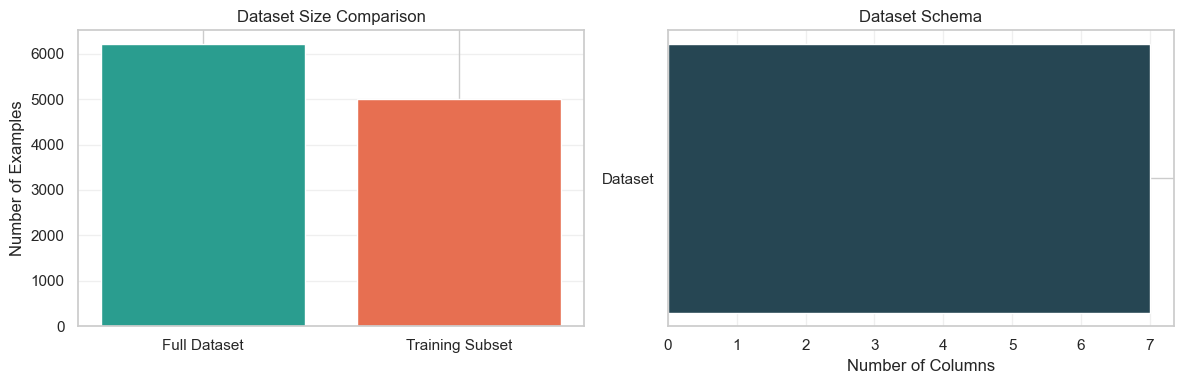


Dataset columns: pre_text, post_text, table, question, answer, exe_list, formatted_prompt


In [10]:
# Visualize dataset size comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dataset size bar chart
axes[0].bar(['Full Dataset', 'Training Subset'], [len(train_dataset), len(train_data)], color=['#2a9d8f', '#e76f51'])
axes[0].set_ylabel('Number of Examples')
axes[0].set_title('Dataset Size Comparison')
axes[0].grid(axis='y', alpha=0.3)

# Column count
axes[1].barh(['Dataset'], [len(train_dataset.column_names)], color='#264653')
axes[1].set_xlabel('Number of Columns')
axes[1].set_title('Dataset Schema')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDataset columns: {', '.join(train_dataset.column_names)}")

## Tokenizer Setup and Prompt Inspection
Load the tokenizer and print a formatted example CoT prompt.

In [11]:
# To switch SLMs, change runtime.model_key to a preset key or direct Hugging Face model id.
# Example: runtime.model_key = "qwen2.5-1.5b" or runtime.model_key = "mistralai/Mistral-7B-Instruct-v0.3"
model_id = resolve_model_id(runtime.model_key)
print(f"Selected model id: {model_id}")

print("Loading tokenizer...")
tokenizer = load_tokenizer(model_id)

sample_prompt = train_data[0][runtime.text_field]
print("Sample formatted_prompt:\n")
print(textwrap.fill(sample_prompt, width=100))

Selected model id: microsoft/Phi-3-mini-4k-instruct
Loading tokenizer...
Sample formatted_prompt:

[INST] You are a highly accurate financial AI. Use the context and table to answer step-by-step.
Context: interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05
% ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100 basis points , our annual
interest expense would change by $ 3.8 million . foreign currency exposure as more fully described
in note 2i . in the notes to consolidated financial statements contained in item 8 of this annual
report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures by entering into
forward foreign currency exchange contracts . the terms of these contracts are for periods matching
the duration of the underlying exposure and generally range from one month to twelve months .
currently , our largest foreign currency exposure is the euro , primarily because our european
operations have the hi

## EDA: Token Length Distribution
Compute token lengths with a progress bar and visualize the distribution.

Computing token lengths: 100%|██████████| 2000/2000 [00:00<00:00, 3938.18 examples/s]


Token length stats -> min: 277 | max: 3143 | mean: 1218.60 | median: 1195.00


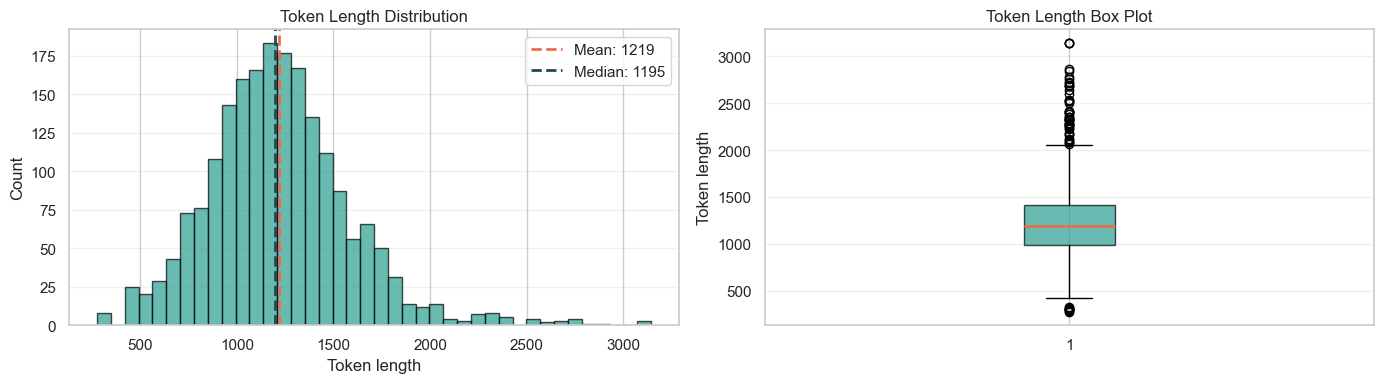


Percentiles:
  25th: 984
  50th: 1195
  75th: 1416
  90th: 1662
  95th: 1818
  99th: 2411


In [12]:
eda_sample = train_data.select(range(min(2000, len(train_data))))

def add_token_length(batch):
    tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

try:
    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]
    print(
        "Token length stats -> "
        f"min: {min(lengths)} | max: {max(lengths)} | mean: {np.mean(lengths):.2f} | median: {np.median(lengths):.2f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram with KDE
    axes[0].hist(lengths, bins=40, color="#2a9d8f", alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(lengths), color='#e76f51', linestyle='--', linewidth=2, label=f'Mean: {np.mean(lengths):.0f}')
    axes[0].axvline(np.median(lengths), color='#264653', linestyle='--', linewidth=2, label=f'Median: {np.median(lengths):.0f}')
    axes[0].set_title("Token Length Distribution")
    axes[0].set_xlabel("Token length")
    axes[0].set_ylabel("Count")
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    axes[1].boxplot(lengths, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2a9d8f', alpha=0.7),
                    medianprops=dict(color='#e76f51', linewidth=2))
    axes[1].set_title("Token Length Box Plot")
    axes[1].set_ylabel("Token length")
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print percentiles
    print(f"\nPercentiles:")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"  {p}th: {np.percentile(lengths, p):.0f}")
        
except Exception as exc:
    print(f"EDA failed: {exc}")

## Quantization Config and Model Load
Load model with 4-bit NF4 and prepare it for QLoRA training.

> **Macbook / Apple Silicon note (important):**
>
> `bitsandbytes` 4-bit QLoRA kernels are CUDA-only. On MPS, this notebook automatically falls back to full precision training and `adamw_torch` optimizer.
> You can still train or debug on Mac, but true QLoRA benchmarking requires a CUDA GPU (NVIDIA).

In [13]:
backend = detect_backend()
print(f"Detected backend: {backend}")

print("Loading model with backend-aware strategy...")
try:
    model, model_runtime_info = load_model_for_training(
        model_id=model_id,
        backend=backend,
        use_qlora=runtime.use_qlora,
        lora_r=runtime.lora_r,
        lora_alpha=runtime.lora_alpha,
        lora_dropout=runtime.lora_dropout,
    )
except Exception as exc:
    raise RuntimeError(
        "Model loading failed. Check model id, internet/auth access, and backend compatibility."
    ) from exc

print("Model runtime info:")
for k, v in model_runtime_info.items():
    print(f"- {k}: {v}")

Detected backend: mps
Loading model with backend-aware strategy...


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.29s/it]
Some parameters are on the meta device because they were offloaded to the disk.


Model runtime info:
- backend: mps
- model_id: microsoft/Phi-3-mini-4k-instruct
- qlora_enabled: False
- lora_enabled: False
- quantization: none
- notes: ['QLoRA/4-bit bitsandbytes is CUDA-only. Running full precision on Apple Silicon.']


## Model Parameter Analysis
Count trainable parameters and visualize model configuration.

Trainable params: 3,821,079,552 / 3,821,079,552 (100.00%)
Full precision mode is active (no 4-bit QLoRA adapters on this backend).


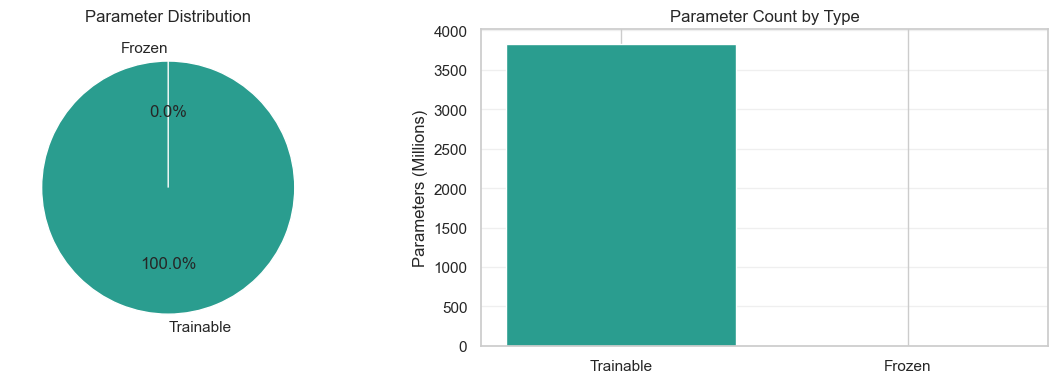

In [14]:
def count_trainable_params(model_obj) -> Tuple[int, int, float]:
    """Count trainable and total parameters."""
    trainable = sum(p.numel() for p in model_obj.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model_obj.parameters())
    pct = 100 * trainable / max(1, total)
    print(f"Trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")
    return trainable, total, pct

model_for_training = model
trainable, total, pct = count_trainable_params(model_for_training)

if model_runtime_info.get("qlora_enabled", False):
    print("QLoRA mode is active (4-bit + LoRA adapters).")
else:
    print("Full precision mode is active (no 4-bit QLoRA adapters on this backend).")

# Visualize parameter breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie([trainable, total - trainable], 
            labels=['Trainable', 'Frozen'],
            colors=['#2a9d8f', '#e9c46a'],
            autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Parameter Distribution')

# Bar chart
axes[1].bar(['Trainable', 'Frozen'], 
            [trainable / 1e6, (total - trainable) / 1e6],
            color=['#2a9d8f', '#e9c46a'])
axes[1].set_ylabel('Parameters (Millions)')
axes[1].set_title('Parameter Count by Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

**Device-aware LoRA/QLoRA logic:**
- On CUDA: LoRA/QLoRA adapters and 4-bit quantization are enabled for efficient training.
- On MPS/CPU: LoRA/QLoRA and quantization are skipped. Training proceeds in full precision. This is slower and more memory-intensive, but avoids unsupported operation errors.

---

## Training/Validation Split
Create an internal validation split from cleaned subset.

Train split: 4750 | Eval split: 250
Using cleaned, deduplicated prompts to reduce data leakage and duplicated supervision.


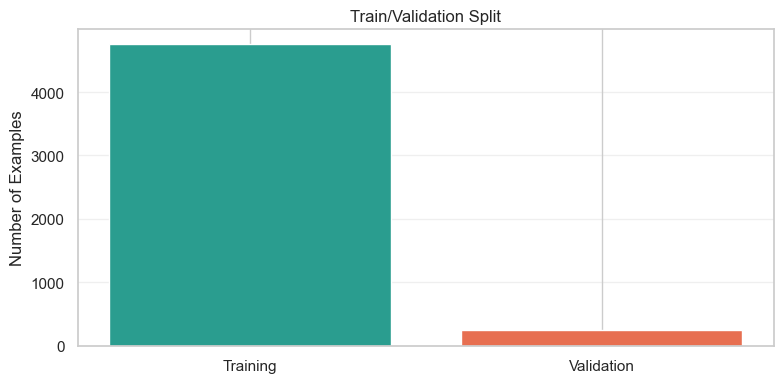

In [15]:
# Thesis-grade split discipline: create an internal validation split from cleaned subset.
split = train_data.train_test_split(test_size=0.05, seed=42)
train_split_data = split["train"]
eval_split_data = split["test"]

print(f"Train split: {len(train_split_data)} | Eval split: {len(eval_split_data)}")
print("Using cleaned, deduplicated prompts to reduce data leakage and duplicated supervision.")

# Visualize split
plt.figure(figsize=(8, 4))
plt.bar(['Training', 'Validation'], [len(train_split_data), len(eval_split_data)], 
        color=['#2a9d8f', '#e76f51'])
plt.ylabel('Number of Examples')
plt.title('Train/Validation Split')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Training Configuration and Logging
Configure TRL SFT settings and optional experiment tracking.

In [16]:
use_wandb = runtime.use_wandb
use_tensorboard = runtime.use_tensorboard

if use_wandb:
    import wandb

    wandb.init(project="fingeo-slm", name=f"{runtime.model_key}-training")

report_to = "wandb" if use_wandb else ("tensorboard" if use_tensorboard else "none")

sft_config = build_sft_config(
    output_dir=runtime.output_dir,
    log_dir=runtime.log_dir,
    report_to=report_to,
    backend=backend,
    qlora_enabled=bool(model_runtime_info.get("qlora_enabled", False)),
    max_seq_length=runtime.max_seq_length,
)

print("Training configuration summary:")
print(f"- backend: {backend}")
print(f"- optimizer: {sft_config.optim}")
print(f"- bf16: {sft_config.bf16} | fp16: {sft_config.fp16}")
print(f"- report_to: {report_to}")
print(f"- output_dir: {runtime.output_dir}")
print(f"- log_dir: {runtime.log_dir}")
print(f"- learning_rate: {sft_config.learning_rate}")
print(f"- per_device_batch_size: {sft_config.per_device_train_batch_size}")
print(f"- gradient_accumulation_steps: {sft_config.gradient_accumulation_steps}")
print(f"- num_train_epochs: {sft_config.num_train_epochs}")

Training configuration summary:
- backend: mps
- optimizer: OptimizerNames.ADAMW_TORCH
- bf16: False | fp16: False
- report_to: tensorboard
- output_dir: fingeo_slm_outputs
- log_dir: fingeo_slm_logs
- learning_rate: 0.0002
- per_device_batch_size: 1
- gradient_accumulation_steps: 8
- num_train_epochs: 1


## Training Loop with Diagnostics
Track loss, profile GPU memory, and persist the model.

In [17]:
loss_history: List[Tuple[int, float]] = []

class LossHistoryCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            loss_history.append((state.global_step, float(logs["loss"])))

trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=train_split_data,
    eval_dataset=eval_split_data,
    args=sft_config,
    processing_class=tokenizer,
    callbacks=[LossHistoryCallback()],
)

training_succeeded = False
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
log_gpu_memory("Before training")

try:
    print("Starting CoT fine-tuning...")
    trainer.train()
    training_succeeded = True
except Exception as exc:
    print(f"Training failed: {exc}")
finally:
    log_gpu_memory("After training")
    if torch.cuda.is_available():
        peak = torch.cuda.max_memory_allocated() / (1024 ** 3)
        print(f"[GPU] Peak allocated={peak:.2f} GB")

if training_succeeded:
    save_dir = runtime.adapter_dir if model_runtime_info.get("lora_enabled", False) else f"{runtime.adapter_dir}-full"
    trainer.model.save_pretrained(save_dir)
    print(f"Training complete. Model artifacts saved to: {save_dir}")

Truncating eval dataset: 100%|██████████| 250/250 [00:00<00:00, 56639.98 examples/s]
The model is already on multiple devices. Skipping the move to device specified in `args`.


[MPS] Before training | allocated=3.74 GB
Starting CoT fine-tuning...


/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Training failed: MPS backend out of memory (MPS allocated: 22.49 GiB, other allocations: 2.94 MiB, max allowed: 22.64 GiB). Tried to allocate 192.00 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).
[MPS] After training | allocated=5.05 GB


## Training Loss Visualization
Plot the loss curve collected by the callback.

In [18]:
if loss_history:
    steps, losses = zip(*loss_history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss curve
    axes[0].plot(steps, losses, marker="o", color="#264653", linewidth=2, markersize=4)
    axes[0].set_title("Training Loss Curve")
    axes[0].set_xlabel("Global step")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    
    # Loss smoothed with moving average
    if len(losses) > 5:
        window = min(5, len(losses) // 3)
        smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
        smooth_steps = steps[window-1:]
        axes[1].plot(steps, losses, alpha=0.3, color="#264653", label="Raw")
        axes[1].plot(smooth_steps, smoothed, color="#e76f51", linewidth=2, label=f"Smoothed (window={window})")
        axes[1].set_title("Training Loss (Smoothed)")
        axes[1].set_xlabel("Global step")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'Not enough data points\nfor smoothing', 
                    ha='center', va='center', transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final loss: {losses[-1]:.4f}")
    if len(losses) > 1:
        print(f"Loss improvement: {losses[0] - losses[-1]:.4f} ({((losses[0] - losses[-1]) / losses[0] * 100):.1f}%)")
else:
    if "trainer" in globals():
        logged = [
            (log["step"], log["loss"])
            for log in trainer.state.log_history
            if "loss" in log
        ]
        if logged:
            steps, losses = zip(*logged)
            plt.figure(figsize=(8, 4))
            plt.plot(steps, losses, marker="o", color="#264653")
            plt.title("Training Loss Curve")
            plt.xlabel("Global step")
            plt.ylabel("Loss")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No loss history recorded.")
    else:
        print("No loss history available.")

No loss history recorded.


## Evaluation Metrics Visualization
If evaluation was performed, visualize evaluation metrics.

In [19]:
if "trainer" in globals() and hasattr(trainer, 'state') and trainer.state.log_history:
    eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]
    
    if eval_logs:
        eval_steps = [log.get('step', i) for i, log in enumerate(eval_logs)]
        eval_losses = [log['eval_loss'] for log in eval_logs]
        
        plt.figure(figsize=(8, 4))
        plt.plot(eval_steps, eval_losses, marker='s', color='#e76f51', linewidth=2, markersize=6, label='Eval Loss')
        plt.title('Evaluation Loss During Training')
        plt.xlabel('Step')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"Best eval loss: {min(eval_losses):.4f} at step {eval_steps[eval_losses.index(min(eval_losses))]}")
    else:
        print("No evaluation metrics found in training logs.")
else:
    print("Trainer not available or training not completed.")

Trainer not available or training not completed.


## End-of-Notebook Validation
Verify that key training artifacts and logs exist after execution.

In [20]:
assert isinstance(train_data, Dataset), "train_data is not a Dataset instance"
assert len(train_data) > 0, "train_data is empty"
assert len(train_split_data) > 0, "train split is empty"
assert len(eval_split_data) > 0, "eval split is empty"
assert os.path.exists(f"./{runtime.output_dir}"), "Output directory missing"
assert os.path.exists(f"./{runtime.log_dir}"), "Log directory missing"

if training_succeeded:
    saved_lora = os.path.exists(runtime.adapter_dir)
    saved_full = os.path.exists(f"{runtime.adapter_dir}-full")
    assert saved_lora or saved_full, "Expected trained model directory missing after successful training"

print("Validation complete: Phase 2 notebook executed end-to-end successfully.")
print(f"\nSummary:")
print(f"- Backend: {backend}")
print(f"- Model: {model_id}")
print(f"- Training samples: {len(train_split_data)}")
print(f"- Validation samples: {len(eval_split_data)}")
print(f"- Training succeeded: {training_succeeded}")

Validation complete: Phase 2 notebook executed end-to-end successfully.

Summary:
- Backend: mps
- Model: microsoft/Phi-3-mini-4k-instruct
- Training samples: 4750
- Validation samples: 250
- Training succeeded: False


In [ ]:
# Save trained model to Google Drive (Colab only)
import shutil
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB and training_succeeded:
    try:
        # Determine which directory was saved
        saved_lora = Path(runtime.adapter_dir).exists()
        saved_full = Path(f"{runtime.adapter_dir}-full").exists()
        
        if not (saved_lora or saved_full):
            print("⚠ No trained model found to save to Drive")
        else:
            # Define paths
            model_source = Path(runtime.adapter_dir) if saved_lora else Path(f"{runtime.adapter_dir}-full")
            drive_base = Path("/content/drive/MyDrive/FinGEO-SLM")
            drive_models = drive_base / "models"
            
            # Check if model is already on Google Drive
            if str(model_source).startswith("/content/drive"):
                print("✓ Model already saved to Google Drive!")
                print(f"  Location: {model_source}")
                print()
                print("ℹ Since PROJECT_ROOT is on Drive, your model is automatically persistent.")
                print("  It will be available in:")
                print("  - Notebook 03 (Evaluation)")
                print("  - Future training sessions")
            else:
                # Model is local, so backup to Drive
                # Determine model type directory
                model_type = runtime.model_key.replace(".", "_")
                drive_model_path = drive_models / model_type
                
                print("📤 Saving trained model to Google Drive...")
                print(f"   Source: {model_source}")
                print(f"   Destination: {drive_model_path}")
                
                # Create Drive directory structure
                drive_models.mkdir(parents=True, exist_ok=True)
                
                # Remove old model if exists
                if drive_model_path.exists():
                    print("  Removing old model from Drive...")
                    shutil.rmtree(drive_model_path)
                
                # Copy model to Drive
                shutil.copytree(model_source, drive_model_path)
                
                # Verify
                saved_files = list(drive_model_path.rglob("*"))
                print(f"✓ Successfully saved model to Google Drive")
                print(f"✓ Total files saved: {len(saved_files)}")
                print(f"✓ Location: {drive_model_path}")
                print()
                print("ℹ This model is now persistent and will be available in:")
                print("  - Notebook 03 (Evaluation)")
                print("  - Future training sessions")
                
                # Also save training logs if they exist
                if Path(runtime.log_dir).exists():
                    drive_logs = drive_base / "logs" / model_type
                    drive_logs.parent.mkdir(parents=True, exist_ok=True)
                    
                    if drive_logs.exists():
                        shutil.rmtree(drive_logs)
                    shutil.copytree(runtime.log_dir, drive_logs)
                    print(f"✓ Training logs saved to: {drive_logs}")
                
    except Exception as e:
        print(f"⚠ Error saving to Google Drive: {e}")
        print("  Your model is still saved locally")
elif IN_COLAB and not training_succeeded:
    print("⚠ Training did not complete successfully - skipping Drive backup")
else:
    print("ℹ Running locally or on Vast.ai - skipping Google Drive backup")
    if training_succeeded:
        saved_lora = Path(runtime.adapter_dir).exists()
        saved_full = Path(f"{runtime.adapter_dir}-full").exists()
        if saved_lora:
            print(f"  Model saved locally at: {runtime.adapter_dir}")
        elif saved_full:
            print(f"  Model saved locally at: {runtime.adapter_dir}-full")

## Save Model to Google Drive (Colab Only)

Automatically save the trained model to Google Drive for persistence across sessions.